<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/ML/kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as np
import numpy as np

In [2]:
X,y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=23)

In [4]:
X.shape

(1000, 2)

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

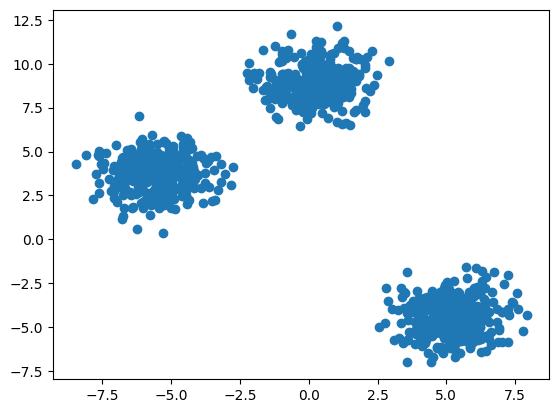

In [25]:
plt.scatter(X[:,0], X[:,1])

In [26]:
from sklearn.cluster import KMeans

In [27]:
# Manual Process
wcss = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, init='k-means++')
  kmeans.fit(X_train)
  wcss.append(kmeans.inertia_)

In [28]:
wcss

[34827.576825520235,
 7935.437286145425,
 1319.2730531585605,
 1181.378499284366,
 1096.6971222705097,
 918.174563473175,
 769.5565163424794,
 677.0217495848958,
 642.6444497764251,
 536.2849422864484]

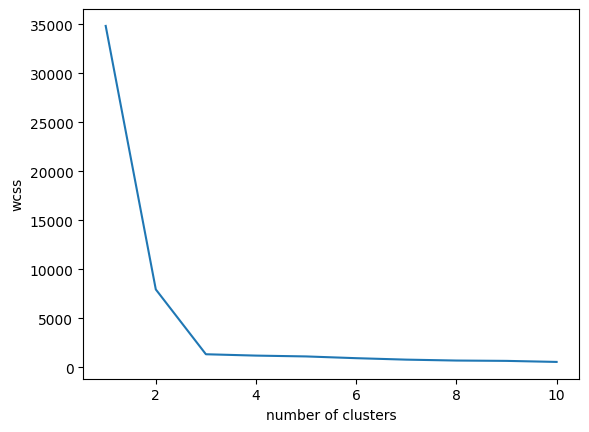

In [29]:
plt.plot(range(1,11),wcss)
# plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel("wcss")
plt.show()

In [30]:
kmeans = KMeans(n_clusters=3, init='k-means++')
y_label = kmeans.fit_predict(X_train)

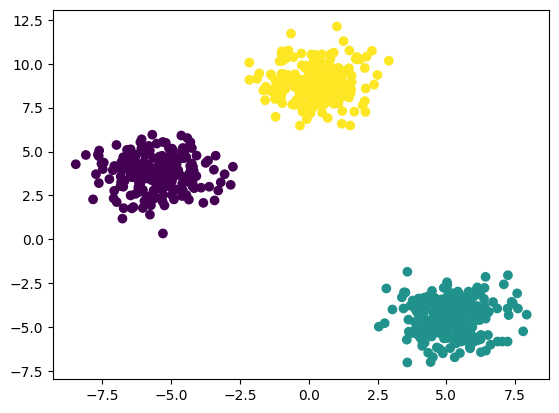

In [31]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_label)

In [32]:
y_test_label = kmeans.predict(X_test)

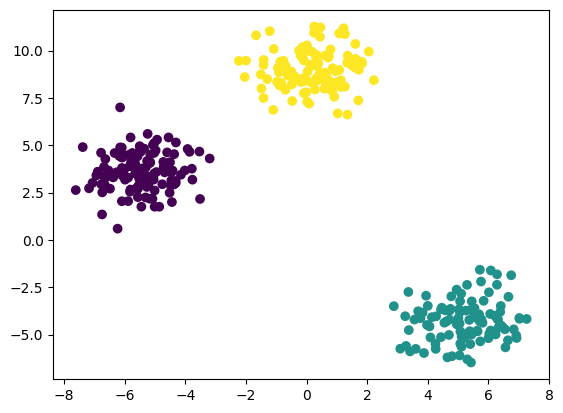

In [35]:
plt.scatter(X_test[:,0], X_test[:,1], c=y_test_label)

In [38]:
#knee locator
!pip install kneed

In [39]:
from kneed import KneeLocator

kl = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
kl.elbow

np.int64(3)

In [40]:
# performance matrix
# silhoutte score

from sklearn.metrics import silhouette_score

In [52]:
silhouette_coefficient = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_train)
    score = silhouette_score(X_train, kmeans.labels_)
    silhouette_coefficient.append(score)

In [53]:
silhouette_coefficient

[np.float64(0.7281443868598331),
 np.float64(0.8071181203797672),
 np.float64(0.6357733426488265),
 np.float64(0.4723297879921876),
 np.float64(0.33367872107343594),
 np.float64(0.32758752735600283),
 np.float64(0.33049705268923796),
 np.float64(0.3233874690312625),
 np.float64(0.32630032779404855)]

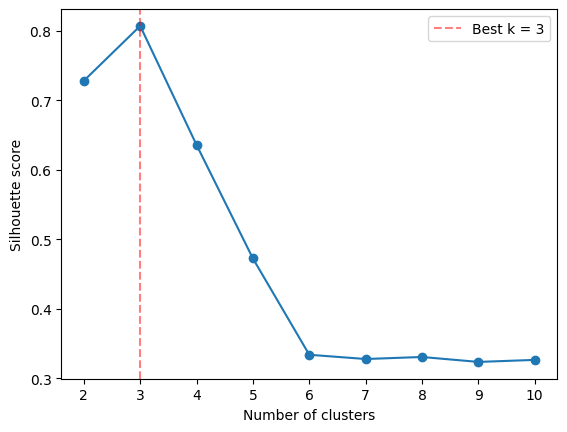

In [54]:
best_k = range(2, 11)[np.argmax(silhouette_coefficient)]

plt.plot(range(2, 11), silhouette_coefficient, marker='o')
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.5, label=f'Best k = {best_k}')
plt.xticks(range(2, 11))
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.legend()
plt.show()

#hierarichal clustering implementation

In [57]:
from sklearn import datasets
import pandas as pd

In [58]:
iris = datasets.load_iris()

In [59]:
iris_data = pd.DataFrame(iris.data)

In [60]:
iris_data.columns=iris.feature_names

In [61]:
iris_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [62]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [63]:
X_scaled = scaler.fit_transform(iris_data)

In [65]:
X_scaled.shape

(150, 4)

In [66]:
from sklearn.decomposition import PCA

In [67]:
pca = PCA(n_components=2)

In [69]:
pca_scaled = pca.fit_transform(X_scaled)

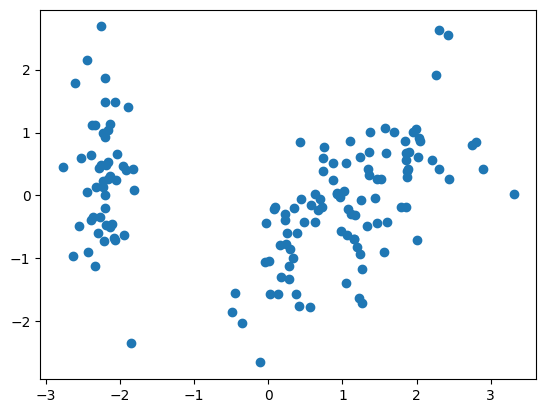

In [71]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1])

Text(0, 0.5, 'eucledian distance')

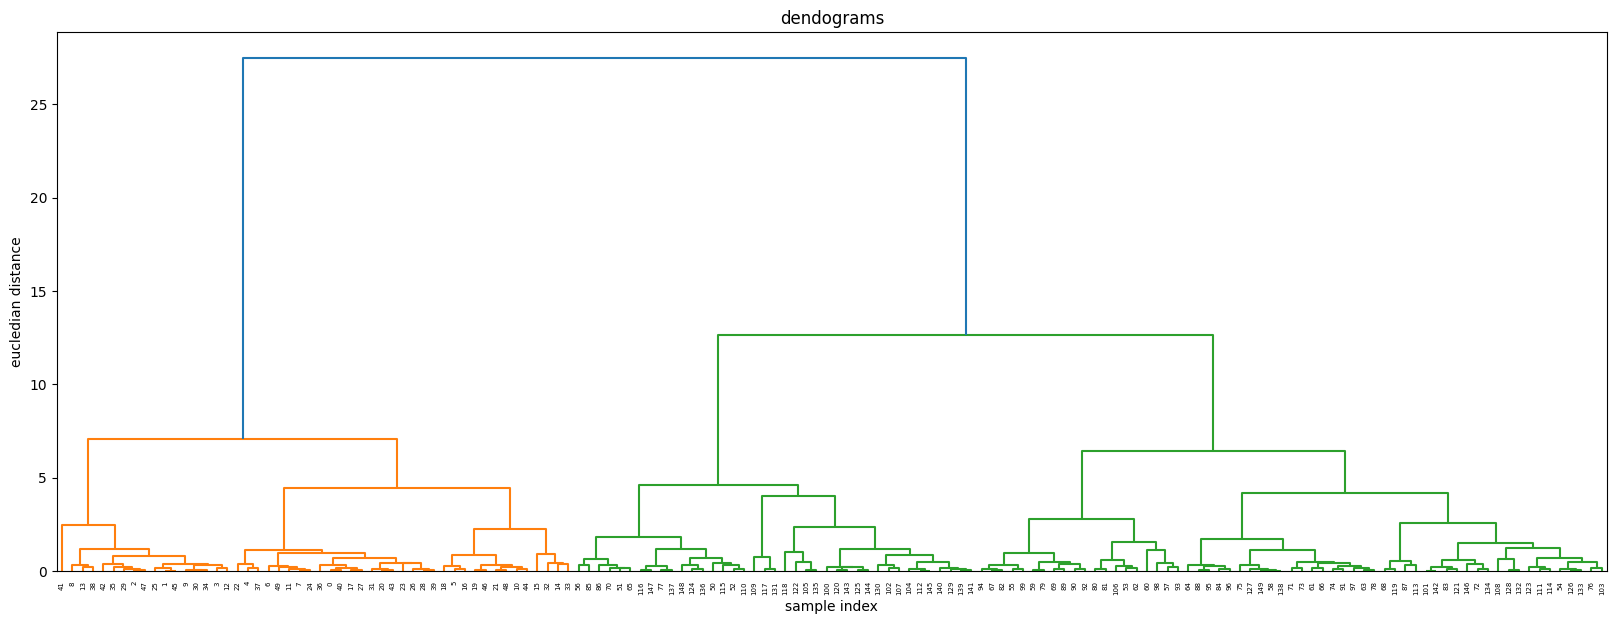

In [72]:
#Agglomerative Clustering
# to construct a dendogram

import scipy.cluster.hierarchy as sc

plt.figure(figsize=(20,7))
plt.title("dendograms")

sc.dendrogram(sc.linkage(pca_scaled, method='ward'))
plt.title("dendograms")
plt.xlabel("sample index")
plt.ylabel('eucledian distance')

In [75]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
cluster.fit(pca_scaled)

AgglomerativeClustering()

In [76]:
cluster.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

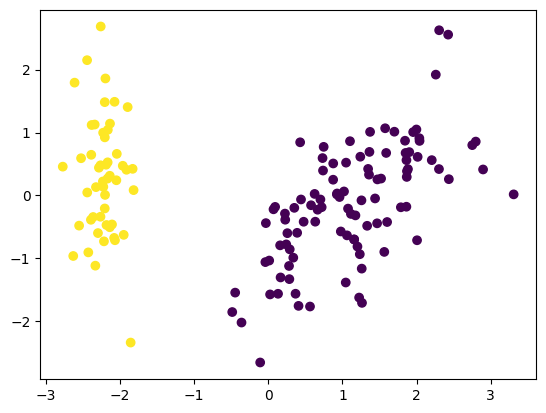

In [77]:
plt.scatter(pca_scaled[:,0], pca_scaled[:,1], c=cluster.labels_)

In [82]:
silhouette_coefficient = []
for k in range(2, 11):
    cluster = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    cluster.fit(pca_scaled)
    score = silhouette_score(pca_scaled, cluster.labels_)
    silhouette_coefficient.append(score)


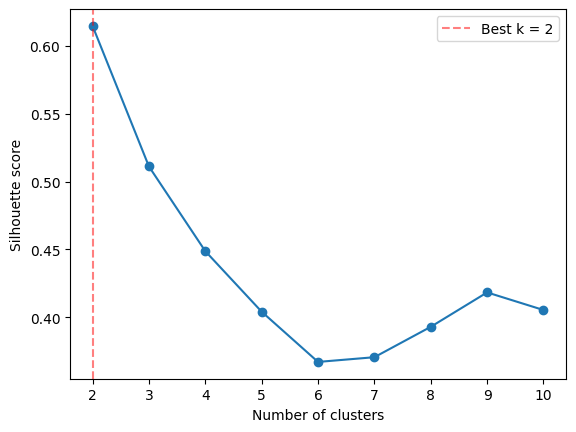

In [83]:
best_k = range(2, 11)[np.argmax(silhouette_coefficient)]

plt.plot(range(2, 11), silhouette_coefficient, marker='o')
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.5, label=f'Best k = {best_k}')
plt.xticks(range(2, 11))
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.legend()
plt.show()

# DBSCANS clustering

In [84]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

In [85]:
X, y = make_moons(n_samples=250, noise=0.05)

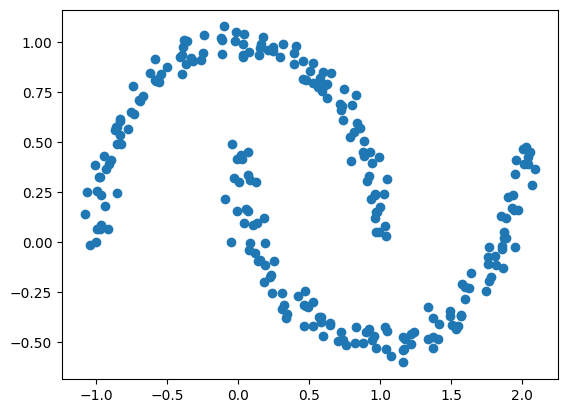

In [86]:
plt.scatter(X[:,0], X[:,1])